In [1]:
title = "# Probabilities: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Probabilities: Exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

## Overview

Both exercises below are classic probability puzzles that are notorious for being unintuitive at first glance. For each one, you will:

1. Work out the probability **analytically**, using the definition of conditional probability and/or Bayes' theorem.
2. Check your answer with a **Monte-Carlo simulation**.

Getting the same answer from both directions is a good way to build confidence that you understand *why* the result holds, not just that you can reproduce a formula.

---
## Exercise 0: Warm-up — dice, sets, and Bayes' theorem

Before the two main exercises, a few short questions to refresh the concepts from the lecture: sample spaces, independence, and Bayes' theorem. These are quick — a couple of lines of code or algebra each.

1. Two fair six-sided dice are rolled. Enumerate the sample space $\Omega$ of the 36 equally-likely $(d_1, d_2)$ outcomes (e.g. with `itertools.product`), and use it to compute $\Pr(\text{sum} = 7)$.
2. Let $A$ be "the sum is 7" and $B$ be "at least one die shows a 4". Are $A$ and $B$ independent? Check using $\Pr(A \mid B) \overset{?}{=} \Pr(A)$.
3. A rare disease affects 0.1% of the population. A test for it is 99% accurate on people who have it, and gives a false positive 2% of the time on people who don't. Using Bayes' theorem, what is $\Pr(\text{disease} \mid \text{positive test})$?

> **Hint.** For question 3: $\Pr(D \mid {+}) = \dfrac{\Pr(+ \mid D)\Pr(D)}{\Pr(+ \mid D)\Pr(D) + \Pr(+ \mid D^c)\Pr(D^c)}$ — the denominator is the law of total probability applied to $\{D, D^c\}$. The answer is smaller than most people expect; that's the point.


In [2]:
# Your code here: work through questions 1-3 above
## Question 1
e = 0
n = 0
for r in itertools.product(range(6),repeat=2):
    roll = (r[0]+1, r[1]+1)
    n += 1
    if sum(roll) == 7:
        e += 1
print(f'Pr(sum=7) = {e}/{n}')

Pr(sum=7) = 6/36


In [3]:
## Question 2
ea = 0
eb = 0
n = 0
for r in itertools.product(range(6),repeat=2):
    roll = (r[0]+1, r[1]+1)
    n += 1
    if sum(roll) == 7:
        ea += 1
    if  4 in roll:
        eb += 1
print(ea)
print(eb)


6
11


---
## Exercise 1: The birthday problem

**Question.** What is the probability that at least two people in this room share a birthday?

More precisely: let $B_n$ be the event that at least two people out of $n$ share a birthday. Find $\Pr(B_n)$.

**Assumptions:**
- Birthdays are independent between people.
- Every day of the year is equally likely to be someone's birthday.
- The year has 365 days (ignore leap years).

### Task

1. It is easier to work with the complementary event $B_n^c$ (no two people share a birthday). Write $\Pr(B_n)$ in terms of $\Pr(B_n^c)$.
2. Introduce the birthday $d_i$ of person $i$, and use independence to write $\Pr(B_n^c)$ as a product of terms, one per person, that each ask "what is the probability this person's birthday differs from everyone before them?"
3. Simplify your product to a closed-form expression for $\Pr(B_n^c)$, and hence for $\Pr(B_n)$.
4. Evaluate $\Pr(B_n)$ for $n = 17$ and $n = 23$. Which of these two group sizes gives roughly even odds?
5. Make a plot of $\Pr(B_n)$ as a function of $n$, for $n$ from 1 to 60. At what $n$ does the room "feel" like a coin flip?

> **Hint.** For step 3, `math.factorial` will overflow or lose precision once $n$ gets large. Consider computing the product directly with `numpy` (e.g. via `np.prod` or `np.cumprod`), or working in log-space with `scipy.special.gammaln`, instead of forming $365!$ explicitly.

> **Bonus.** How does the answer change on a planet where the year has a different number of days? Turn your expression for $\Pr(B_n)$ into a function of both $n$ and the number of days in the year, and see how the "50% group size" scales.

#### Your analytic derivation

*(Write your derivation of $\Pr(B_n)$ here, e.g. using LaTeX in this markdown cell.)*

\begin{align}
  Pr(B_n) &= 1 - Pr(B_n^c) \\
  Pr(B_n^c) &= 1 \cdot \frac{364}{365} \cdot \frac{363}{365} ... = \frac{365!}{365^n\cdot(365-n)!}
\end{align}


In [4]:
# Your code here: implement Pr(B_n) and evaluate it for n = 17 and n = 23
import math

def Pr_Bn_v0 (n,days=365):
    return 1 - math.factorial(days) / ( days**n * math.factorial(days-n) )

def Pr_Bn_v1 (n,days=365):
    return 1 - np.prod( np.arange(days-n+1,days+1) /days )
    

Pr_Bn = Pr_Bn_v1

# days = 365
# n = 2
# print(np.arange(days-n+1,days+1))

print(f'Pr(B_n) for n = 17: {Pr_Bn(17)}')
print(f'Pr(B_n) for n = 23: {Pr_Bn(23)}')



Pr(B_n) for n = 17: 0.31500766529656055
Pr(B_n) for n = 23: 0.5072972343239853


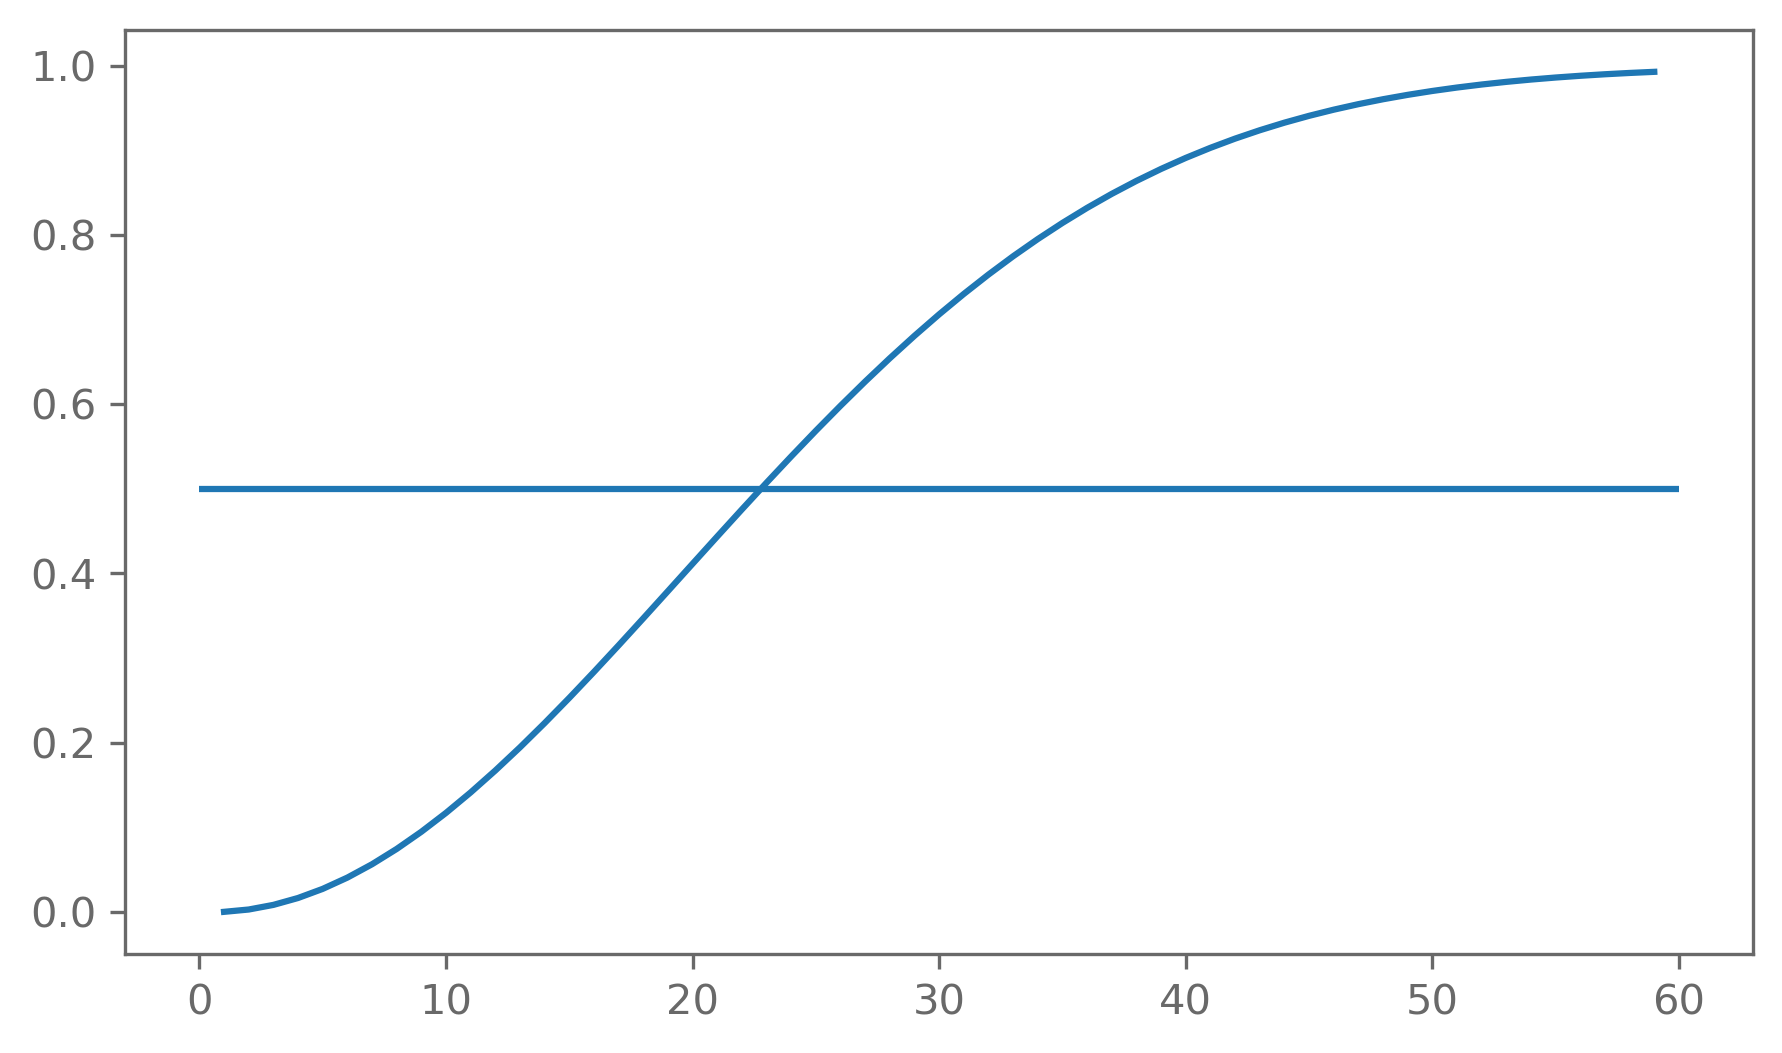

In [5]:
# Your code here: plot Pr(B_n) as a function of n
ns = np.arange(1,60)
plt.figure()
plt.plot(ns,[Pr_Bn(n) for n in ns])
plt.hlines(0.5,0,60)
plt.show()

---
## Exercise 2: The Monty Hall problem

**Setup.** In a game show, a contestant is presented with three doors. Behind one door is a car, and behind the other two are goats. The goal is to win the car.

The game proceeds as follows:
1. The contestant chooses a door, which stays closed for now.
2. The host, who knows where the car is, opens one of the *other two* doors, always revealing a goat.
3. The contestant may now **stick** with their original door, or **switch** to the remaining closed door.

**Question.** What is the best strategy? Concretely, suppose the contestant first chooses door 1 and the host opens door 3 (revealing a goat). What is $\Pr(C_1 \mid H_3)$, the probability of winning by sticking, versus $\Pr(C_2 \mid H_3)$, the probability of winning by switching?

### Task

You are free to tackle these two parts in either order — each is a useful check on the other.

**A. Simulate the game.**
1. Write a function that plays one round: randomly place the car, have the contestant pick a door, have the host open a door with a goat behind it (excluding the contestant's door and the car's door), and record whether *sticking* or *switching* would have won.
2. Repeat for many rounds (e.g. $10^5$) and estimate $\Pr(\text{win} \mid \text{stick})$ and $\Pr(\text{win} \mid \text{switch})$ from the simulated frequencies.

**B. Derive it analytically.**
1. Write out $\Pr(C_1 \mid H_3)$ using Bayes' theorem:
$$\Pr(C_1 \mid H_3) = \frac{\Pr(H_3 \mid C_1)\,\Pr(C_1)}{\Pr(H_3)}$$
2. Work out each ingredient: the prior $\Pr(C_i)$ for each door, and the likelihood $\Pr(H_3 \mid C_i)$ for each door (i.e. how likely is the host to open door 3, given where the car actually is?).
3. Expand the denominator $\Pr(H_3)$ by summing over the three possible car locations, and put everything together.
4. Compare $\Pr(C_1 \mid H_3)$ and $\Pr(C_2 \mid H_3)$ to your simulated estimates from part A.

> **Hint.** The denominator $\Pr(H_3)$ is the same for both $\Pr(C_1\mid H_3)$ and $\Pr(C_2\mid H_3)$. If you only care about *which* strategy is better, you can sidestep computing it entirely by looking at the posterior odds $\Pr(C_2 \mid H_3) / \Pr(C_1 \mid H_3)$ instead.

> **Bonus.** How do the winning probabilities change if there are $N > 3$ doors, with the host still opening $N - 2$ goat-doors one at a time before offering the switch?

In [6]:
import random

In [7]:
# Your code here: simulate the Monty Hall game and estimate
# Pr(win | stick) and Pr(win | switch)

def game( n, doors=3, verbose=0):
    
    car_doors = np.random.randint(0, doors, size=n) # car behind door 0, 1, or 2 (for doors = 3)
    # player allways starts with picking door 0
    host_doors = np.where(car_doors == 1, 2, 1) # host points at door 2 if car behind 1, else points at door 1
    wins_sticks = np.where(car_doors == 0, 1, 0)
    wins_switchs = ( car_doors == np.where(host_doors == 1, 2, 1) ).astype(int)
        
    w_stick = np.sum(wins_sticks)
    w_switch = np.sum(wins_switchs)
    
    if verbose > 0: print(f'with n = {n} and {doors} doors: sticking wins {w_stick} times and switching wins {w_switch} times')

    return w_stick/n, w_switch/n

n = int( 1e5 )
game(n, verbose=1)


with n = 100000 and 3 doors: sticking wins 33562 times and switching wins 66438 times


(np.float64(0.33562), np.float64(0.66438))

In [10]:
Ns = np.linspace(10, 1e7, 100).astype(int)

# w_sticks, w_switchs = np.vectorize(game)(Ns)
results = [game(n) for n in Ns]
w_sticks, w_switchs = map(np.array, zip(*results))

plt.figure()
plt.plot(Ns,1/3 - w_sticks,label='stick')
plt.plot(Ns,2/3 - w_switchs,label='switch')
plt.yscale('log')
plt.legend()
plt.show()

#### Your analytic derivation

*(Write your derivation of $\Pr(C_1 \mid H_3)$ and $\Pr(C_2 \mid H_3)$ here.)*

\begin{align}

\end{align}